Available sheets: ['concrete', 'wood', 'insulated_concrete']
Index(['time', 'Ti', 'Ta', 'P', 'dt'], dtype='object')


,time,Ti,Ta,P,dt
0,2018-06-13 09:00:00,29.2,23.9,14.25,60
1,2018-06-13 09:01:00,29.6,23.9,14.25,60
2,2018-06-13 09:02:00,30.0,23.9,14.25,60
3,2018-06-13 09:03:00,30.3,23.9,14.25,60
4,2018-06-13 09:04:00,30.7,23.9,14.25,60


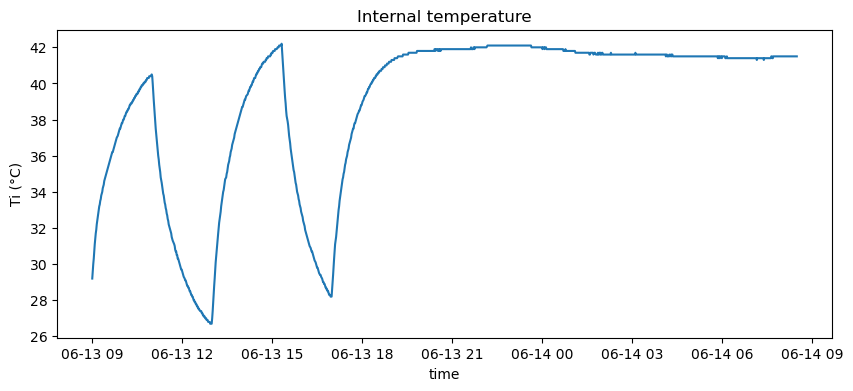

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILEPATH = "test_box.xlsx" 

def load_test_box(sheet_name=0, filepath=FILEPATH):
    """
    Load one experimental run from test_box.xlsx.

    Parameters
    ----------
    sheet_name : str or int
        Sheet name (e.g., 'concrete') or sheet index (e.g., 0).
    filepath : str
        Path to the Excel file.

    Returns
    -------
    df : pandas.DataFrame
        Cleaned dataframe with missing values interpolated.
    """
    # Read the sheet
    df = pd.read_excel(filepath, sheet_name=sheet_name)

    df.columns = [c.strip() for c in df.columns]

    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time").reset_index(drop=True)

    for col in ["Ti", "Ta", "P", "dt"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.interpolate(limit_direction="both")

    return df

def list_sheets(filepath=FILEPATH):
    """Convenience helper to see available runs/sheets."""
    return pd.ExcelFile(filepath).sheet_names

print("Available sheets:", list_sheets())

df = load_test_box(0)
print(df.columns)
display(df.head())

# quick plot test
if "time" in df.columns and "Ti" in df.columns:
    plt.plot(df["time"], df["Ti"])
    plt.xlabel("time")
    plt.ylabel("Ti (°C)")
    plt.title("Internal temperature")
    plt.show()

In [80]:
# We can implement this function as Python code to calculate the next step Ti
def ti(inputs, R, C):
    
    ta = inputs[:,0]   # ambient temp
    p  = inputs[:,1]   # power input
    dt = inputs[:,2]   # timestep
    y = np.zeros(len(inputs))
    y[0] = inputs[3,0] # use first value from data 

    for t in range(1,len(y)):
        y[t] = 1/(C/dt[t]+1/R) * (C/dt[t]*y[t-1] + 1/R*ta[t] + p[t])
    return y

In [18]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

FILEPATH = "test_box.xlsx"

def load_test_box(sheet_name="concrete", filepath=FILEPATH):
    df = pd.read_excel(filepath, sheet_name=sheet_name)
    df.columns = [c.strip() for c in df.columns]
    for col in ["Ti", "Ta", "P", "dt"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.interpolate(limit_direction="both").reset_index(drop=True)
    return df

def simulate_Ti(Ta, P, dt, Ti0, R, C):
    """Discrete 1R1C simulation producing Ti(t) given inputs and parameters."""
    Ta = np.asarray(Ta, dtype=float)
    P  = np.asarray(P, dtype=float)
    dt = np.asarray(dt, dtype=float)

    y = np.empty_like(Ta, dtype=float)
    y[0] = Ti0
    invR = 1.0 / R

    for t in range(1, len(y)):
        a = C / dt[t]  # uses dt for step t
        y[t] = (a * y[t-1] + invR * Ta[t] + P[t]) / (a + invR)

    return y

def fit_RC_for_sheet(sheet_name):
    df = load_test_box(sheet_name)
    Ta = df["Ta"].to_numpy()
    P  = df["P"].to_numpy()
    dt = df["dt"].to_numpy()
    Ti = df["Ti"].to_numpy()
    Ti0 = Ti[0]

    xdata = np.vstack([Ta, P, dt]).T

    def model(x, R, C):
        return simulate_Ti(x[:,0], x[:,1], x[:,2], Ti0, R, C)

    # initial guess + bounds (R>0, C>0)
    p0 = [0.5, 5000.0]
    bounds = ([1e-6, 1e-3], [1e3, 1e9])

    popt, pcov = curve_fit(model, xdata, Ti, p0=p0, bounds=bounds, maxfev=20000)
    R_hat, C_hat = popt
    return R_hat, C_hat

for sheet in ["concrete", "wood", "insulated_concrete"]:
    R_hat, C_hat = fit_RC_for_sheet(sheet)
    print(f"{sheet:18s}  R = {R_hat:.4f} K/W,   C = {C_hat:.2f} J/K,   tau=R*C={R_hat*C_hat/3600:.3f} h")

concrete            R = 1.2334 K/W,   C = 2278.23 J/K,   tau=R*C=0.781 h
wood                R = 1.9225 K/W,   C = 1405.70 J/K,   tau=R*C=0.751 h
insulated_concrete  R = 2.1745 K/W,   C = 1429.52 J/K,   tau=R*C=0.863 h


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot formatting
plt.rcParams["figure.figsize"] = (10, 4)
df = pd.read_csv("input_data.csv", parse_dates=["Time"])
df = df.sort_values("Time").reset_index(drop=True)

time = df["Time"].values
To = df["To"].values          # Outdoor temperature [°C]
Isol = df["I_sol"].values     # Solar irradiance [W/m^2]
hea_on = df["hea_on"].values  # Baseline schedule (0/1), optional

dt = 900  # seconds (15 minutes)
dt_hours = dt / 3600

df.head()

,Time,To,I_sol,hea_on
0,2019-06-01 00:00:00,5.00,0.0,0
1,2019-06-01 00:15:00,4.85,0.0,0
2,2019-06-01 00:30:00,4.70,0.0,0
3,2019-06-01 00:45:00,4.55,0.0,0
4,2019-06-01 01:00:00,4.40,0.0,0


In [20]:
class Building:
    def __init__(self, Ti, Te, Ri, Ro, Ci, Ce, Ai, Ae, dt=900):
        self.Ri = Ri  # [K/W]
        self.Ro = Ro  # [K/W]
        self.Ci = Ci  # [J/K]
        self.Ce = Ce  # [J/K]
        self.Ai = Ai  # [m^2]
        self.Ae = Ae  # [m^2]
        self.Ti = Ti  # [°C]
        self.Te = Te  # [°C]
        self.dt = dt  # [s]

    def next_step(self, P_hea, To, I_sol):
        dt = self.dt

        self.Ti = self.Ti + (dt / self.Ci) * (
            (self.Te - self.Ti) / self.Ri
            + P_hea
            + self.Ai * I_sol
        )
        self.Te = self.Te + (dt / self.Ce) * (
            (self.Ti - self.Te) / self.Ri
            + (To - self.Te) / self.Ro
            + self.Ae * I_sol
        )

    def get_state(self):
        return float(self.Ti), float(self.Te)

In [21]:
# --- Given model parameters (do not change) ---
Ri = 4.50e-03  # [K/W] indoor ↔ envelope thermal resistance
Ro = 5.80e-02  # [K/W] envelope ↔ outdoor thermal resistance
Ci = 5.80e+06  # [J/K] indoor thermal capacitance
Ce = 2.05e+07  # [J/K] envelope thermal capacitance
Ai = 3.20e-01  # [m^2] indoor solar gain coefficient
Ae = 2.20e-01  # [m^2] envelope solar gain coefficient

# Initial conditions
Ti0 = 20.0  # [°C]
Te0 = 20.0  # [°C]

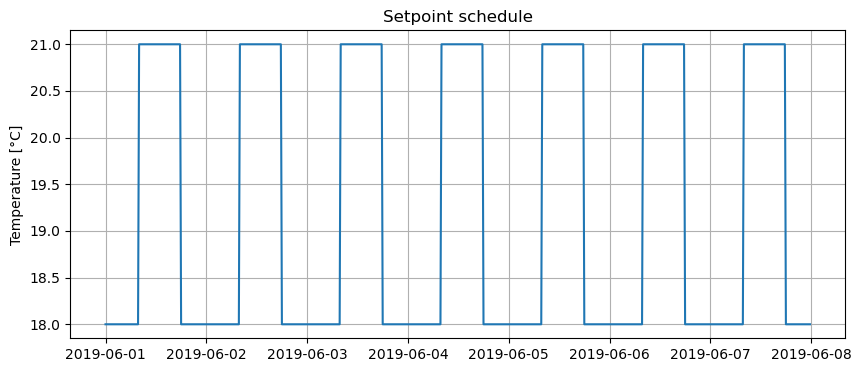

In [32]:
def is_occupied(ts: np.datetime64) -> bool:
    # Convert to pandas Timestamp for convenient hour extraction
    t = pd.Timestamp(ts)
    return (t.hour >= 8) and (t.hour < 18)

def get_setpoint(ts: np.datetime64, sp_occ=21.0, sp_unocc=18.0) -> float:
    return sp_occ if is_occupied(ts) else sp_unocc

# Visualize the setpoint profile
sp_profile = np.array([get_setpoint(t) for t in time])
plt.plot(time, sp_profile, label="Setpoint")
plt.title("Setpoint schedule")
plt.ylabel("Temperature [°C]")
plt.grid(True)
plt.show()

In [33]:
def p_controller(Ti: float, Tsp: float, Kp: float, Pmax: float, deadband: float = 0.0) -> float:

    # temperature error (positive => need heating)
    e = Tsp - Ti

    # optional deadband to reduce chattering near setpoint
    if deadband > 0.0 and e <= deadband:
        return 0.0

    # proportional control law
    u = Kp * e

    # no cooling + saturation
    if u < 0.0:
        u = 0.0
    if u > Pmax:
        u = Pmax

    return float(u)

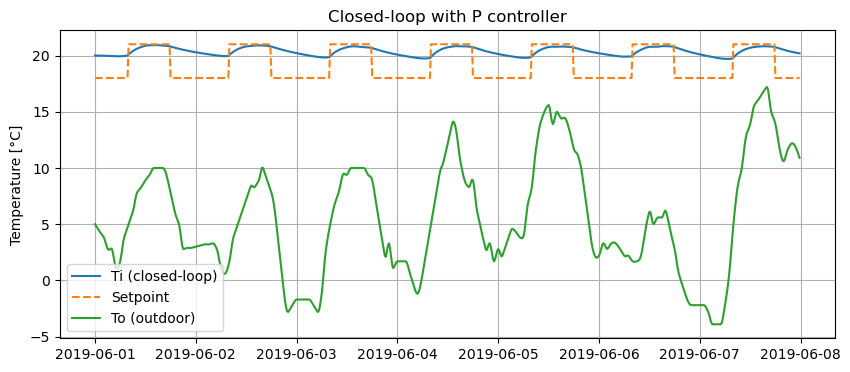

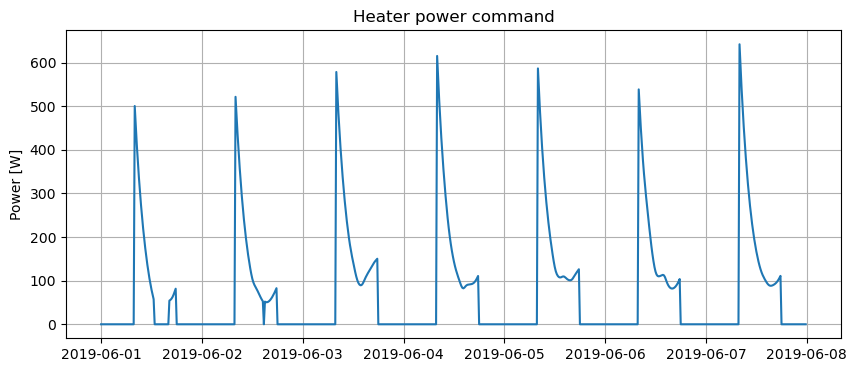

In [35]:
def simulate_closed_loop(Kp: float, Pmax: float, deadband: float = 0.0, Ti0=Ti0, Te0=Te0,
                         sp_occ: float = 21.0, sp_unocc: float = 18.0):
    bldg = Building(Ti=Ti0, Te=Te0, Ri=Ri, Ro=Ro, Ci=Ci, Ce=Ce, Ai=Ai, Ae=Ae, dt=dt)
    N = len(time)
    Ti_hist = np.zeros(N)
    Te_hist = np.zeros(N)
    Phea_hist = np.zeros(N)
    Tsp_hist = np.zeros(N)

    for k in range(N):
        Ti_k, Te_k = bldg.get_state()
        Tsp_k = get_setpoint(time[k], sp_occ=sp_occ, sp_unocc=sp_unocc)

        P_k = p_controller(Ti=Ti_k, Tsp=Tsp_k, Kp=Kp, Pmax=Pmax, deadband=deadband)

        bldg.next_step(P_k, To[k], Isol[k])

        Ti_hist[k], Te_hist[k] = bldg.get_state()
        Phea_hist[k] = P_k
        Tsp_hist[k] = Tsp_k

    return Ti_hist, Te_hist, Phea_hist, Tsp_hist

Kp_example = 500.0
Pmax_example = 5000.0
deadband_example = 0.1

Ti_cl, Te_cl, Phea_cl, Tsp_cl = simulate_closed_loop(Kp=Kp_example, Pmax=Pmax_example, deadband=deadband_example)

plt.plot(time, Ti_cl, label="Ti (closed-loop)")
plt.plot(time, Tsp_cl, "--", label="Setpoint")
plt.plot(time, To, label="To (outdoor)")
plt.title("Closed-loop with P controller")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(time, Phea_cl, label="Phea [W]")
plt.title("Heater power command")
plt.ylabel("Power [W]")
plt.grid(True)
plt.show()

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pid_controller(
    Ti,
    Tsp,
    Kp,
    Ki,
    Kd,
    dt_seconds,
    integral_prev,
    error_prev,
    Pmax,
    deadband=0.0
):
    """
    PID controller for heating-only system.

    Parameters
    ----------
    Ti : float
        Current indoor temperature [°C]
    Tsp : float
        Temperature setpoint [°C]
    Kp, Ki, Kd : float
        PID gains
    dt_seconds : float
        Simulation timestep [s]
    integral_prev : float
        Previous integral state
    error_prev : float
        Previous error
    Pmax : float
        Maximum heating power [W]
    deadband : float
        Deadband around setpoint [°C]

    Returns
    -------
    u : float
        Heater power [W]
    integral_new : float
        Updated integral term
    error : float
        Current error
    derivative : float
        Current derivative term
    """
    error = Tsp - Ti

    # deadband
    if abs(error) <= deadband:
        error = 0.0

    dt_hours = dt_seconds / 3600.0

    # derivative
    if dt_hours > 0:
        derivative = (error - error_prev) / dt_hours
    else:
        derivative = 0.0

    # candidate integral
    integral_candidate = integral_prev + error * dt_hours

    # unsaturated PID output
    u_unsat = Kp * error + Ki * integral_candidate + Kd * derivative

    # heating only: clamp to [0, Pmax]
    u = max(0.0, min(Pmax, u_unsat))

    # simple anti-windup
    pushing_upper = (u >= Pmax) and (error > 0)
    pushing_lower = (u <= 0.0) and (error < 0)

    if pushing_upper or pushing_lower:
        integral_new = integral_prev
    else:
        integral_new = integral_candidate

    return float(u), float(integral_new), float(error), float(derivative)

In [37]:
def simulate_closed_loop_pid(
    time_array,
    To_array,
    Isol_array,
    dt_sim,
    Ri,
    Ro,
    Ci,
    Ce,
    Ai,
    Ae,
    Ti0,
    Te0,
    Kp,
    Ki,
    Kd,
    Pmax,
    get_setpoint_func,
    deadband=0.0,
    sp_occ=21.0,
    sp_unocc=18.0
):
    """
    Closed-loop simulation with PID controller.
    """

    bldg = Building(
        Ti=Ti0,
        Te=Te0,
        Ri=Ri,
        Ro=Ro,
        Ci=Ci,
        Ce=Ce,
        Ai=Ai,
        Ae=Ae,
        dt=dt_sim
    )

    N = len(time_array)

    Ti_hist = np.zeros(N)
    Te_hist = np.zeros(N)
    Phea_hist = np.zeros(N)
    Tsp_hist = np.zeros(N)
    err_hist = np.zeros(N)
    int_hist = np.zeros(N)
    der_hist = np.zeros(N)

    integral = 0.0
    error_prev = 0.0

    for k in range(N):
        Ti_k, Te_k = bldg.get_state()

        Tsp_k = get_setpoint_func(
            time_array[k],
            sp_occ=sp_occ,
            sp_unocc=sp_unocc
        )

        P_k, integral, error_now, derivative_now = pid_controller(
            Ti=Ti_k,
            Tsp=Tsp_k,
            Kp=Kp,
            Ki=Ki,
            Kd=Kd,
            dt_seconds=dt_sim,
            integral_prev=integral,
            error_prev=error_prev,
            Pmax=Pmax,
            deadband=deadband
        )

        # building step
        bldg.next_step(P_k, To_array[k], Isol_array[k])

        Ti_new, Te_new = bldg.get_state()

        Ti_hist[k] = Ti_new
        Te_hist[k] = Te_new
        Phea_hist[k] = P_k
        Tsp_hist[k] = Tsp_k
        err_hist[k] = error_now
        int_hist[k] = integral
        der_hist[k] = derivative_now

        error_prev = error_now

    return {
        "Ti": Ti_hist,
        "Te": Te_hist,
        "Phea": Phea_hist,
        "Tsp": Tsp_hist,
        "err": err_hist,
        "integral": int_hist,
        "derivative": der_hist
    }

In [38]:
df_ctrl = pd.read_csv("input_data.csv", parse_dates=["Time"])
df_ctrl = df_ctrl.sort_values("Time").reset_index(drop=True)

time_ctrl = df_ctrl["Time"].values
To_ctrl = df_ctrl["To"].values
Isol_ctrl = df_ctrl["I_sol"].values
hea_on_ctrl = df_ctrl["hea_on"].values

dt_sim = 900  # 15 min

print("time length =", len(time_ctrl))
print("To shape =", To_ctrl.shape)
print("Isol shape =", Isol_ctrl.shape)
print("dt_sim =", dt_sim)

time length = 672
To shape = (672,)
Isol shape = (672,)
dt_sim = 900


In [40]:
pid_result = simulate_closed_loop_pid(
    time_array=time_ctrl,
    To_array=To_ctrl,
    Isol_array=Isol_ctrl,
    dt_sim=dt_sim,
    Ri=Ri,
    Ro=Ro,
    Ci=Ci,
    Ce=Ce,
    Ai=Ai,
    Ae=Ae,
    Ti0=Ti0,
    Te0=Te0,
    Kp=500.0,
    Ki=200.0,
    Kd=5,
    Pmax=5000.0,
    get_setpoint_func=get_setpoint,
    deadband=0.1,
    sp_occ=27.0,
    sp_unocc=23.0
)

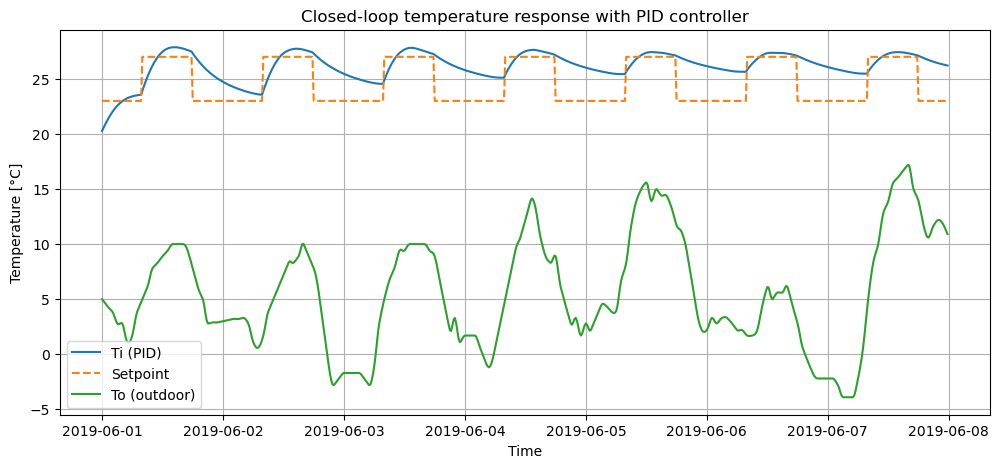

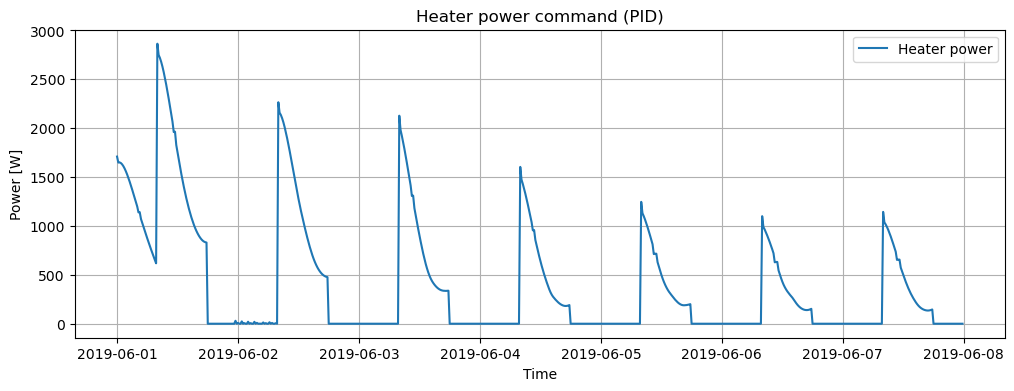

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(time_ctrl, pid_result["Ti"], label="Ti (PID)")
plt.plot(time_ctrl, pid_result["Tsp"], "--", label="Setpoint")
plt.plot(time_ctrl, To_ctrl, label="To (outdoor)")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Closed-loop temperature response with PID controller")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_ctrl, pid_result["Phea"], label="Heater power")
plt.xlabel("Time")
plt.ylabel("Power [W]")
plt.title("Heater power command (PID)")
plt.legend()
plt.grid(True)
plt.show()